# Ungraded Lab: Supervised Learning Challenge Lab

## Task 1: Data Preparation

<b>Step 1:</b> Environment Setup

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

df = pd.read_csv('smart_city_incidents_uncleaned.csv')
df.head()

<b>Step 2:</b> Data Inspection

In [ ]:
# Display basic information about the dataset
print("Dataset Shape:", < YOUR CODE HERE >)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
< YOUR CODE HERE >

**Assess Data Quality:**
- What data quality issues do you observe?
- Which columns might need type conversion?

## Task 2: Data Cleaning and Preprocessing
<b>Step 1:</b> Handle Missing Values

In [ ]:
# Fill numerical columns with missing values
numeric_cols = ['response_team_rating', 'issue_complexity'] for col in numeric_cols:
    < YOUR CODE HERE >  # Fill missing values with appropriate method

# Fill categorical columns
categorical_cols = ['issue_type']
for col in categorical_cols:
    < YOUR CODE HERE >  # Fill missing values with appropriate method

<b>Step 2:</b> Feature Engineering

In [ ]:
# Create relevant features for modeling
df['timestamp'] = < YOUR CODE HERE >
df['hour_of_day'] = < YOUR CODE HERE >  # Extract hour from timestamp
df['day_of_week'] = < YOUR CODE HERE >  # Extract day of week

# Encode categorical variables
# Format neighborhood names: remove spaces and capitalize
< YOUR CODE HERE >

df = pd.get_dummies(df, columns=['neighborhood', 'issue_type'], drop_first=True)

**Review Feature Engineering:**

- What additional features might be useful?
- How might you handle outliers?

## Task 3: Regression Modeling

<b>Step 1:</b> Prepare Data for Resolution Time Prediction

In [ ]:
# Select features for regression
regression_features = [
    'severity_score',
    'num_previous_reports',
    'is_weekend',
    'weather_rain'
    # Add additional relevant features
]

X_reg = df[regression_features]
y_reg = df['time_to_resolution']

# Split and scale data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

<b>Step 2:</b> Data Scaling

In [ ]:
# Create a scaler to normalize the features values
< YOUR CODE HERE >

# Fit the scaler on the training data and transform it
X_train_scaled = < YOUR CODE HERE >

# Use the same transformation on the test data
X_test_scaled = < YOUR CODE HERE >

<b>Step 3:</b> Build and Evaluate Regression Model

In [ ]:
# Initialize and train model
reg_model = LinearRegression()
< YOUR CODE HERE >  # Fit the model

# Make predictions and evaluate
y_reg_pred = reg_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

**Evaluate Model Results:**
- How would you improve the model's performance?
- What insights can you draw from the coefficients?

## Task 4: Classification Modeling

<b>Step 1:</b> Prepare Data for Escalation Prediction

In [ ]:
# Select features for classification
classification_features = [
    'severity_score',
    'time_to_resolution',
    'num_previous_reports',
    # Add additional relevant features
]

X_cls = df[classification_features]
y_cls = df['required_escalation']

# Split data
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

<b>Step 2:</b> Data Scaling

In [ ]:
# Create a scaler to normalize the features values
< YOUR CODE HERE >

# Fit the scaler on the training data and transform it
X_train_scaled_cls = < YOUR CODE HERE >

# Use the same transformation on the test data
X_test_scaled_cls = < YOUR CODE HERE >

<b>Step 3:</b> Build and Evaluate Classification Model

In [ ]:
# Initialize and train model
cls_model = LogisticRegression()
< YOUR CODE HERE >  # Fit the model

# Make predictions and evaluate
y_cls_pred = cls_model.predict(X_test_scaled_cls)
accuracy = accuracy_score(y_cls_test, y_cls_pred)
precision = precision_score(y_cls_test, y_cls_pred)
recall = recall_score(y_cls_test, y_cls_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

## Task 5: Results Analysis  
<b>Step 1:</b> Visualize Results

In [ ]:
# Plot actual vs predicted resolution times
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'r--', lw=2)
plt.xlabel('Actual Resolution Time')
plt.ylabel('Predicted Resolution Time')
plt.title('Resolution Time: Actual vs Predicted')
plt.show()

<b>Step 2:</b> Document Business Insights

**Analyze and document:**
- Key factors affecting resolution time
- Patterns in escalation needs
- Recommendations for resource allocation


## Solution Code
Need a hand or are curious to compare your approach? Below is a complete solution you can use as a reference. This is just one of many valid ways to solve the problem. Make sure to give it a try on your own first. Use this implementation to troubleshoot, learn new techniques, or confirm your logic. Keep experimenting and enjoy the process!

## Task 1: Data Preparation Solution Code

<b>Step 1:</b> Environment Setup

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score

import matplotlib.pyplot as plt

df = pd.read_csv('smart_city_incidents_uncleaned.csv')

<b>Step 2:</b> Data Inspection

In [5]:

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 14)

Data Types:
report_id                object
timestamp                object
neighborhood             object
issue_type               object
time_to_resolution      float64
required_escalation       int64
num_previous_reports      int64
severity_score          float64
is_weekend                int64
weather_rain              int64
response_team_rating    float64
reporter_experience     float64
issue_complexity        float64
hour_of_day             float64
dtype: object

Missing Values:
report_id                0
timestamp                0
neighborhood             0
issue_type               8
time_to_resolution       0
required_escalation      0
num_previous_reports     0
severity_score           0
is_weekend               0
weather_rain             0
response_team_rating     2
reporter_experience      0
issue_complexity         3
hour_of_day             14
dtype: int64


## Task 2: Data Cleaning and Preprocessing Solution Code

<b>Step 1:</b> Handle Missing Values

In [6]:
# Fill numerical columns with missing values
numeric_cols = ['response_team_rating', 'issue_complexity']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
categorical_cols = ['issue_type']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

<b>Step 2:</b> Feature Engineering

In [7]:
# Create relevant features for modeling
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

# Encode categorical variables
# Format neighborhood names: remove spaces and capitalize
df['neighborhood'] = df['neighborhood'].str.strip().str.title()

df = pd.get_dummies(df, columns=['neighborhood', 'issue_type'], drop_first=True)

## Task 3: Regression Modeling Solution Code

<b>Step 1:</b> Prepare Data for Resolution Time Prediction

In [8]:
# Select features for regression
regression_features = [
    'severity_score',
    'num_previous_reports',
    'is_weekend',
    'weather_rain',
    'hour_of_day']

X_reg = df[regression_features]
y_reg = df['time_to_resolution']

# Split and scale data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

<b>Step 2:</b> Data Scaling

In [9]:
# Create a scaler to normalize the features values
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_reg_train)

# Use the same transformation on the test data
X_test_scaled = scaler.transform(X_reg_test)

<b>Step 3:</b> Build and Evaluate Regression Model

In [10]:
# Initialize and train model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_reg_train)

# Make predictions and evaluate
y_reg_pred = reg_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 16.94
R² Score: 0.27


## Task 4: Classification Modeling Solution Code

<b>Step 1:</b> Prepare Data for Escalation Prediction

In [11]:
# Select features for classification
classification_features = [
    'severity_score',
    'time_to_resolution',
    'num_previous_reports']

X_cls = df[classification_features]
y_cls = df['required_escalation']

# Split data
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

<b>Step 2:</b> Data Scaling

In [12]:
# Create a scaler to normalize the features values
scaler_cls = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled_cls = scaler_cls.fit_transform(X_cls_train)

# Use the same transformation on the test data
X_test_scaled_cls = scaler_cls.transform(X_cls_test)

<b>Step 3:</b> Build and Evaluate Classification Model

In [13]:
# Initialize and train model
cls_model = LogisticRegression()
cls_model.fit(X_train_scaled_cls, y_cls_train)

# Make predictions and evaluate
y_cls_pred = cls_model.predict(X_test_scaled_cls)
accuracy = accuracy_score(y_cls_test, y_cls_pred)
precision = precision_score(y_cls_test, y_cls_pred)
recall = recall_score(y_cls_test, y_cls_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

Accuracy: 0.810
Precision: 0.667
Recall: 0.510


## Task 5: Results Analysis Solution Code
<b>Step 1:</b> Visualize Results

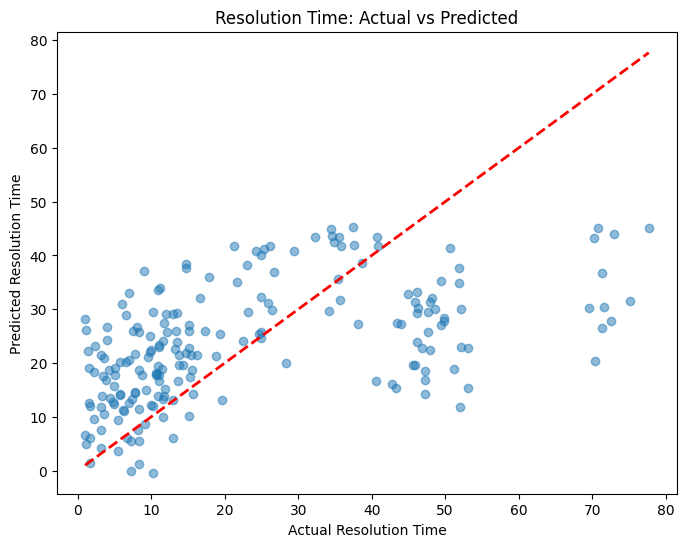

In [14]:
# Plot actual vs predicted resolution times
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'r--', lw=2)
plt.xlabel('Actual Resolution Time')
plt.ylabel('Predicted Resolution Time')
plt.title('Resolution Time: Actual vs Predicted')
plt.show()

<b>Step 2:</b> Document Business Insights
- Key factors affecting resolution time

In [15]:
# Get feature names and coefficients
features = X_reg.columns
coefficients = reg_model.coef_

# Create a summary DataFrame
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

                Feature  Coefficient
0        severity_score    10.670549
3          weather_rain     0.779860
2            is_weekend     0.549216
4           hour_of_day    -0.160546
1  num_previous_reports     0.090513


// **Key factors affecting resolution time:**

**Severity score (10.67):**
For each one-unit increase in severity score, the resolution time **increases by about 10.67 units** (e.g., hours). This shows severity is the strongest driver of longer resolution times.


**Weather rain (0.78):**
When it’s raining, resolution time tends to increase by about 0.78 units, indicating weather has a small but noticeable impact on delays.


**Is weekend (0.55):**
Cases reported on weekends take about 0.55 units longer to resolve, suggesting weekend staffing or availability affects speed.


**Hour of day (-0.16):**
For each hour later in the day, resolution time decreases by roughly 0.16 units, which may indicate cases reported later are resolved faster or receive different handling.


**Number of previous reports (0.09):**
Each additional previous report slightly increases resolution time by 0.09 units, reflecting that repeat issues add complexity.

- Patterns in escalation needs

In [16]:
# Get feature names and model coefficients
features = X_cls.columns
coefficients = cls_model.coef_[0]

# Create a DataFrame for easier interpretation
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

# Sort by absolute value to find strongest predictors
coef_df['abs_coef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

print(coef_df[['Feature', 'Coefficient']])

                Feature  Coefficient
0        severity_score     1.435778
1    time_to_resolution     0.357818
2  num_previous_reports     0.111793


// **Patterns in escalation needs**

**Severity score (1.44):**
A higher severity score strongly increases the likelihood of escalation. Specifically, for each one-unit increase in severity score, the log-odds of escalation increase by about 1.44.

**Time to resolution (0.36):**
Longer resolution times also raise the chance of escalation, though with a smaller effect than severity. Each additional unit increase in resolution time increases the log-odds of escalation by 0.36.

**Number of previous reports (0.11):**
More previous reports slightly increase escalation risk, suggesting recurring problems contribute but less strongly than severity or resolution time.

// **Recommendations for Resource Allocation**

**Keep a close eye on repeat issues.** Problems that keep coming back are more likely to escalate, so it’s worth having a dedicated team or special process to handle these quickly and effectively.

**Don’t let long-running cases slip through the cracks.** If a case is taking longer than usual, it’s a good idea to step in early to offer extra support before things escalate.

**Focus extra resources on high-severity cases.** These are the ones that usually cause the most trouble, so assigning experienced staff can help resolve them faster and prevent escalation.